In [1]:
import quanguru as qg
import numpy as np
import matplotlib.pyplot as plt

# 15 - Time dependent Hamiltonian 2

In previous tutorials, we covered how to set an initial state to a quantum system and how to describe its Hamiltonian.

Here, we will evolve the quantum system under the unitary dynamics of its Hamiltonian.
First, we create a quantum system and describe its Hamiltonian 

$H=f_{z}J_{z} + f_{d}(t)\sigma_{+} + f_{d}^{*}(t)\sigma_{-}$

where the second and third term will be time dependent.


## Define the system and parameters

We create a single qubit whose static Hamiltonian is set by $J_{z}$ with frequency $f_{z}=\texttt{qubFreq}$.
Then we add a second term with operator $\sigma_{+}$ and third term with operator $\sigma_{-}$ with time-dependent frequencies.

The relevant information are:

- frequency: `qubFreq` for the static term and a time-dependent frequency for the drive
- operator: `Jz` for the qubit, `sigma_p` and  `sigma_m` for the drive
- dimension: `2` for a qubit

We also compute useful derived quantities:

- $\Omega_R = g\,A$ is the Rabi frequency set by coupling strength and drive amplitude
- $\Delta = f_{z} - f_{\text{drive}}$ is the detuning
- $\Omega = \sqrt{\Omega_R^2 + \Delta^2}$ is the generalized Rabi frequency

In [2]:
# define parameters
qubFreq = 1
driveFreq = 2
driveAmp = 1
drivePhase = 0
couplingStrength = 1

OmegaR = couplingStrength*driveAmp
detun = qubFreq-driveFreq
Omega = np.sqrt((OmegaR**2) + (detun**2))

We set the initial state to `1` (excited state for the qubit) and choose a total simulation time of one drive period with a small step size.
We then provide a `compute` function that records the expectation value $\langle\sigma_x\rangle$ at each time step.

In [3]:
qub = qg.QuantumSystem(operator=qg.Jz)
qub.dimension = 2
qub.frequency = qubFreq

# add the drive terms 
secondTerm = qub.createTerm(operator=qg.sigmap)
secondTerm.frequency = driveFreq

thirdTerm = qub.createTerm(operator=qg.sigmam)
thirdTerm.frequency = driveFreq

# set the initial state
qub.initialState = 1

# set the simulation time and step size
qub.simTotalTime = 2*np.pi
qub.simStepSize = 0.01

# create the operators for which we compute the expectation values
sigmaX = qg.sigmax()

# write a compute function that takes two arguments: (i) a quantum-system (qsys) and (ii) a state
# compute whatever we want and store in .resultsDict
def compute(qsys, state):
    qsys.resultsDict['sigmax expectation'].append(qg.expectation(sigmaX, state))

# set the compute attribute of our qubit to compute function
qub.compute = compute

C:\Users\Josh\Desktop\Masters Project\QuanGuru Code\QuanGuru\src\quanguru\classes\QSystem.py:353: UserWarning: QuantumSystem1 type (whether it is a single or composite system) is ambiguousIf it is intentional, please ignore this
  warnings.warn(f'{self.name} type (whether it is a single or composite system) is ambiguous'+\


## Time-dependent terms via callbacks

We implement time dependence by assigning unique functions to the `timeDependency` attribute of each term.
These functions receive two arguments:

- `st`: the term (or system) whose attributes we will update
- `ti`: the current simulation time

For the raising term $\sigma_{+}$, we use a cosine modulation:

$f_{+}(t) = gA\cos\big(2\pi f_{\text{drive}}\,t + \phi\big)$

For the lowering term $\sigma_{-}$, we use a complex exponential (negative-phase) modulation:

$f_{-}(t) = -gAe^{-i\big(2\pi f_{\text{drive}}\,t + \phi\big)}$

This approach is flexible and applies to any `QuantumSystem` or `Term` object.

In [4]:
# def secondTermTime(st, ti):
#     return -driveAmp*couplingStrength*np.exp(1j*(2*np.pi*driveFreq*ti + drivePhase))

def secondTermTime(st, ti):
    st.frequency = couplingStrength*driveAmp*np.cos(2*np.pi*driveFreq*ti + drivePhase)

def thirdTermTime(st, ti):
    st.frequency =  -driveAmp*couplingStrength*np.exp(-1j*(2*np.pi*driveFreq*ti + drivePhase))

secondTerm.timeDependency = secondTermTime
thirdTerm.timeDependency = thirdTermTime

At this point, all the essential information are set, and we can run the simulation by `qub.runSimulation()`, which returns the list of states for the time evolution of our `QuantumSystem`.

In [5]:
states = qub.runSimulation()

We verify that the number of propagator exponentiations equals the step count, which confirms the integrator advanced at the requested resolution.


In [6]:
# The number of exponentiations should be equal to the step count
print(qub._freeEvol.numberOfExponentiations, qub._freeEvol.numberOfExponentiations == qub.simulation.stepCount)

628 True


Finally, we plot $\langle\sigma_x\rangle$ against time.

Text(0, 0.5, 'Sigma X Expectation Value $\\langle\\sigma_x\\rangle$')

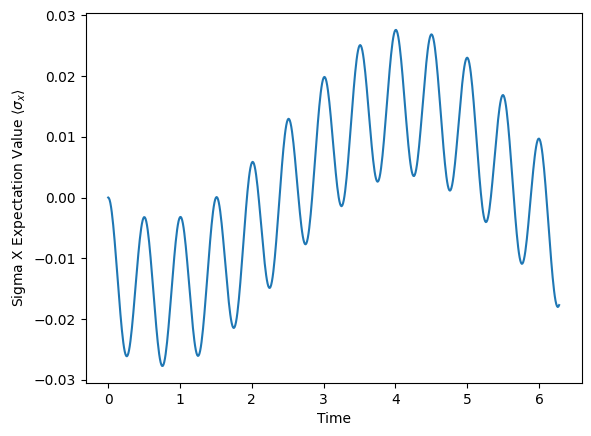

In [7]:
plt.plot(qub.simulation.timeList, qub.resultsDict['sigmax expectation'])
plt.xlabel('Time')
plt.ylabel(r'Sigma X Expectation Value $\langle\sigma_x\rangle$')

## Understanding Time-Dependent Hamiltonian Equivalence


This tutorial demonstrates a driven qubit system using **two time-dependent terms** with raising ($\sigma_+$) and lowering ($\sigma_-$) operators. Interestingly, this produces the same output as the simpler single-term approach in tutorial 14, which uses only $\sigma_x$.

### The Hamiltonians

**Tutorial 14** (single drive term):
$$H_{T14} = f_z J_z + f_x(t)\sigma_x$$

where $f_x(t) = gA\cos(2\pi f_{\text{drive}}t + \phi)$

**Tutorial 15** (two drive terms):
$$H_{T15} = f_z J_z + f_+(t)\sigma_+ + f_-(t)\sigma_-$$

where:
- $f_+(t) = gA\cos(2\pi f_{\text{drive}}t + \phi)$ for the raising operator
- $f_-(t) = -gAe^{-i(2\pi f_{\text{drive}}t + \phi)}$ for the lowering operator

### Mathematical Equivalence

The key insight is the **Pauli matrix identity**:
$$\sigma_x = \sigma_+ + \sigma_-$$

Expanding the drive terms in Tutorial 15:

$$\begin{align}
f_+(t)\sigma_+ + f_-(t)\sigma_- &= gA\cos(\omega t)\sigma_+ - gAe^{-i\omega t}\sigma_- \\
&= gA\frac{e^{i\omega t} + e^{-i\omega t}}{2}\sigma_+ - gAe^{-i\omega t}\sigma_-
\end{align}$$

where $\omega = 2\pi f_{\text{drive}}t + \phi$.

After algebraic manipulation, the fast-rotating terms (at $\pm 2\omega$) average to zero, leaving:

$$f_+(t)\sigma_+ + f_-(t)\sigma_- \approx gA\cos(\omega t)(\sigma_+ + \sigma_-) = gA\cos(\omega t)\sigma_x$$

This **exactly matches** the drive term in Tutorial 14.


